In [506]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split


In [507]:
df = pd.read_csv(r"C:\Users\amar0\Downloads\Teen_Mental_Health_Dataset.csv")

In [508]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [509]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [510]:
df['gender'].value_counts

<bound method IndexOpsMixin.value_counts of 0         male
1       female
2       female
3         male
4       female
         ...  
1195    female
1196      male
1197    female
1198      male
1199    female
Name: gender, Length: 1200, dtype: object>

In [511]:
df['daily_social_media_hours'].value_counts()

daily_social_media_hours
3.5    28
4.0    26
3.8    25
7.4    24
7.2    24
       ..
4.3    11
1.9    10
6.7    10
4.9     8
1.0     4
Name: count, Length: 71, dtype: int64

In [512]:
df['platform_usage'].value_counts()

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

In [513]:
df['sleep_hours'].value_counts()

sleep_hours
7.4    34
6.8    34
5.7    33
4.4    32
8.0    32
5.3    31
8.6    31
5.1    30
6.7    29
4.2    29
6.4    28
7.5    28
6.3    28
4.1    27
7.1    26
4.3    26
8.2    26
4.7    25
7.0    25
8.4    25
4.5    25
7.2    24
6.5    24
7.3    24
5.8    24
5.0    24
4.6    23
4.9    23
8.7    23
7.8    23
6.1    22
5.4    22
8.8    22
6.9    22
5.6    21
8.9    21
6.0    21
4.8    20
7.6    20
5.2    20
7.9    19
8.5    19
5.5    18
6.6    18
7.7    18
5.9    17
8.1    17
6.2    15
8.3    12
4.0    10
9.0    10
Name: count, dtype: int64

In [514]:
df['screen_time_before_sleep'].value_counts

<bound method IndexOpsMixin.value_counts of 0       2.9
1       2.9
2       0.5
3       1.6
4       3.0
       ... 
1195    2.0
1196    1.9
1197    0.7
1198    2.1
1199    1.0
Name: screen_time_before_sleep, Length: 1200, dtype: float64>

In [515]:
df['academic_performance'].value_counts

<bound method IndexOpsMixin.value_counts of 0       3.01
1       3.22
2       3.92
3       3.48
4       2.37
        ... 
1195    2.76
1196    2.12
1197    3.98
1198    3.19
1199    2.91
Name: academic_performance, Length: 1200, dtype: float64>

In [516]:
df['physical_activity'].value_counts

<bound method IndexOpsMixin.value_counts of 0       1.5
1       0.8
2       0.0
3       0.8
4       1.4
       ... 
1195    1.0
1196    0.4
1197    0.8
1198    0.6
1199    0.9
Name: physical_activity, Length: 1200, dtype: float64>

In [517]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [518]:
df['social_interaction_level'].value_counts

<bound method IndexOpsMixin.value_counts of 0          low
1         high
2         high
3       medium
4       medium
         ...  
1195       low
1196      high
1197      high
1198      high
1199    medium
Name: social_interaction_level, Length: 1200, dtype: object>

In [519]:
df['stress_level'].value_counts

<bound method IndexOpsMixin.value_counts of 0       2
1       8
2       2
3       1
4       3
       ..
1195    3
1196    7
1197    1
1198    7
1199    5
Name: stress_level, Length: 1200, dtype: int64>

In [520]:
df['anxiety_level'].value_counts

<bound method IndexOpsMixin.value_counts of 0       2
1       1
2       4
3       7
4       5
       ..
1195    4
1196    4
1197    1
1198    9
1199    7
Name: anxiety_level, Length: 1200, dtype: int64>

In [521]:
df['addiction_level'].value_counts

<bound method IndexOpsMixin.value_counts of 0        1
1       10
2        2
3        9
4        2
        ..
1195     4
1196     4
1197     1
1198     9
1199     3
Name: addiction_level, Length: 1200, dtype: int64>

In [522]:
df['depression_label'].value_counts

<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       0
3       0
4       0
       ..
1195    0
1196    0
1197    0
1198    0
1199    0
Name: depression_label, Length: 1200, dtype: int64>

In [523]:
num_features = [col for col in df.columns if df[col].dtype != 'O']

In [524]:
print(num_features)

['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']


In [525]:
cat_feature = [col for col in df.columns if df[col].dtypes == 'O']
cat_feature 

['gender', 'platform_usage', 'social_interaction_level']

In [526]:
##Spending hours 
time = df.groupby(['age', 'sleep_hours'])['daily_social_media_hours'].mean()

In [527]:
time

age  sleep_hours
13   4.1            5.437500
     4.2            4.266667
     4.3            3.966667
     4.4            4.520000
     4.5            3.740000
                      ...   
19   8.6            3.566667
     8.7            3.333333
     8.8            5.500000
     8.9            5.800000
     9.0            4.666667
Name: daily_social_media_hours, Length: 349, dtype: float64

In [528]:
## average of stress level,anixetiy,depression level
df['Total_average']=df['stress_level']+df['anxiety_level']+df['depression_label']
df['ave']=df['Total_average']/3

In [529]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label', 'Total_average',
       'ave'],
      dtype='object')

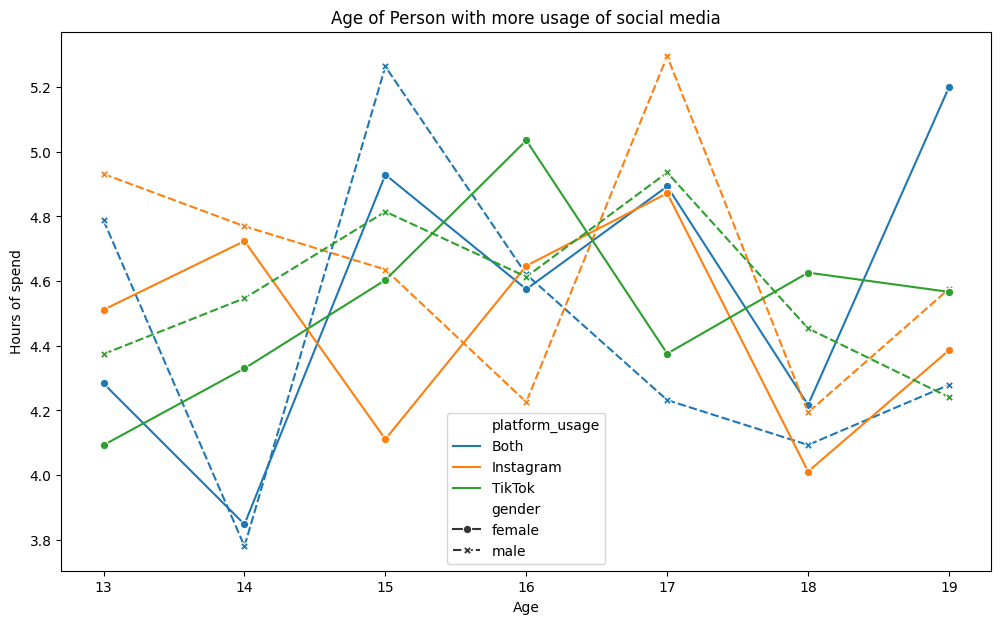

In [530]:
grouped = df.groupby(['age','gender','platform_usage'])['daily_social_media_hours'].mean().reset_index()

plt.figure(figsize=(12,7))

sns.lineplot(data=grouped,
             x='age',
             y='daily_social_media_hours',
             hue='platform_usage',
             style='gender',
             markers=True
)

plt.title("Age of Person with more usage of social media")
plt.xlabel('Age')
plt.ylabel('Hours of spend')
plt.show()

In [531]:
soc = df[['gender', 'academic_performance', 'social_interaction_level']]

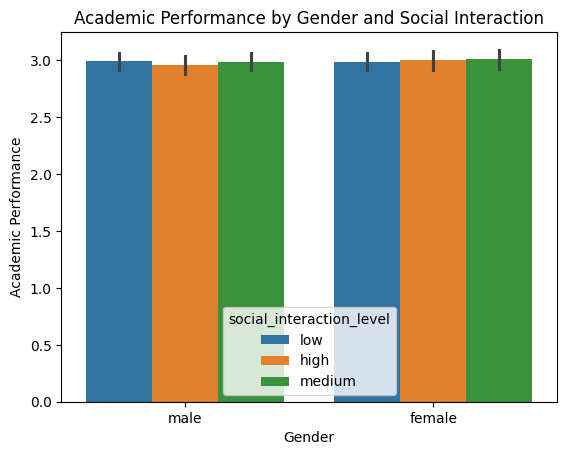

In [532]:
sns.barplot(
    data=soc,
    x='gender',
    y='academic_performance',
    hue='social_interaction_level'
)

plt.title("Academic Performance by Gender and Social Interaction")
plt.xlabel("Gender")
plt.ylabel("Academic Performance")

plt.show()

In [533]:
df.head(4)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,Total_average,ave
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,4,1.333333
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,9,3.000000
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,6,2.000000
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0,8,2.666667


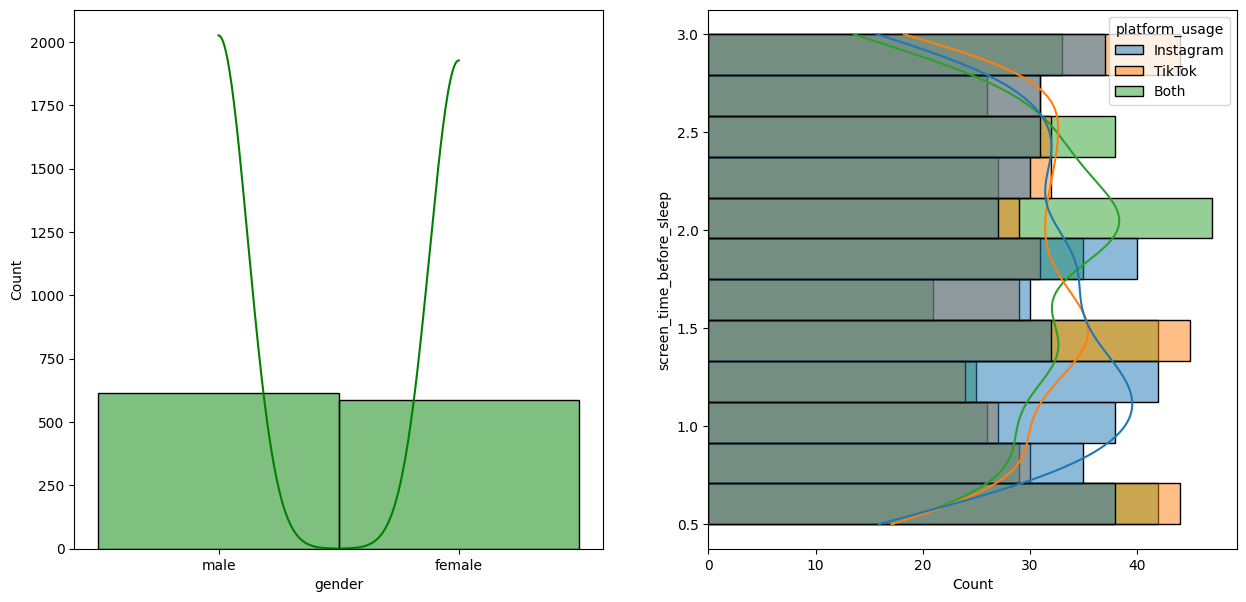

In [534]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))

plt.subplot(121)
sns.histplot(data=df,x='gender',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,y='screen_time_before_sleep',kde=True,hue='platform_usage')
plt.show()

In [535]:
df_copy=df

In [536]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label', 'Total_average',
       'ave'],
      dtype='object')

In [537]:
X = df_copy.drop('depression_label',axis=1)
y=df_copy['depression_label']

In [538]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor


In [539]:
num_feat=X.select_dtypes(exclude='object').columns
cat_feat=X.select_dtypes(include='object').columns


In [540]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

trans = OneHotEncoder()
stand = StandardScaler()

procees = ColumnTransformer([
    ("oneHotEncoder",trans,cat_feat),
    ("StandardScaler",stand,num_feat)
])

In [541]:
X = procees.fit_transform(X)

In [542]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [543]:
def module_training (true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2_square = r2_score(true,predicted)
    return mae, rmse, r2_square

In [544]:
##Linear LinearRegression

liners = LinearRegression()
liners.fit(X_train,y_train)

y_pred = liners.predict(X_test)


mae, rmse, r2 = module_training(y_test, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 1.5082148493069287e-15
RMSE : 1.8755447719214873e-15
R2 Score : 1.0


In [545]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbour Regressor": KNeighborsRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
}

model_list = []
r2_list = []

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_predict_train = model.predict(X_train)
    y_predict_test = model.predict(X_test)

    # Training metrics
    mae, rmse, r2 = module_training(y_train, y_predict_train)

    # Testing metrics
    maes, rmsew, r2w = module_training(y_test, y_predict_test)

    print(f"Model: {name}")

    print("Train Data")
    print("Mean Absolute Error: {:.4f}".format(mae))
    print("Root Mean Squared Error: {:.4f}".format(rmse))
    print("R2 Score: {:.4f}".format(r2))

    print('__________________________')

    print("Test Data")
    print("Mean Absolute Error: {:.4f}".format(maes))
    print("Root Mean Squared Error: {:.4f}".format(rmsew))
    print("R2 Score: {:.4f}".format(r2w))

    r2_list.append(r2w)

    print('=' * 35)
    print('\n')

Model: LinearRegression
Train Data
Mean Absolute Error: 0.0000
Root Mean Squared Error: 0.0000
R2 Score: 1.0000
__________________________
Test Data
Mean Absolute Error: 0.0000
Root Mean Squared Error: 0.0000
R2 Score: 1.0000


Model: Lasso
Train Data
Mean Absolute Error: 0.0498
Root Mean Squared Error: 0.1578
R2 Score: 0.0000
__________________________
Test Data
Mean Absolute Error: 0.0509
Root Mean Squared Error: 0.1611
R2 Score: -0.0000


Model: Ridge
Train Data
Mean Absolute Error: 0.0391
Root Mean Squared Error: 0.0829
R2 Score: 0.7240
__________________________
Test Data
Mean Absolute Error: 0.0423
Root Mean Squared Error: 0.0862
R2 Score: 0.7136


Model: K-Neighbour Regressor
Train Data
Mean Absolute Error: 0.0244
Root Mean Squared Error: 0.1058
R2 Score: 0.5502
__________________________
Test Data
Mean Absolute Error: 0.0320
Root Mean Squared Error: 0.1275
R2 Score: 0.3733


Model: RandomForestRegressor
Train Data
Mean Absolute Error: 0.0048
Root Mean Squared Error: 0.0288
R2 S

In [546]:
## Logic regression

Log = LogisticRegression()
test = Log.fit(X_train,y_train)
y_predict=Log.predict(X_test)
print(y_predict)



[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0]


In [547]:
test

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


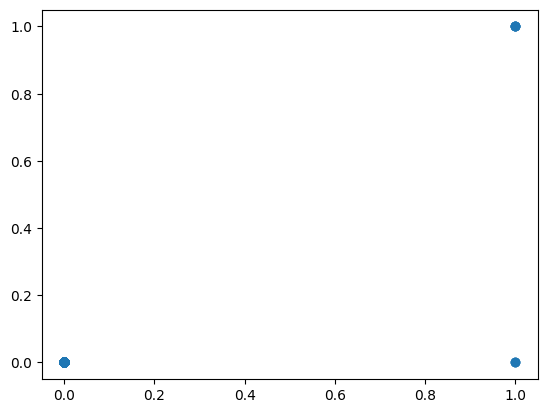

In [548]:
plt.scatter(y_test,y_predict)

<Axes: xlabel='depression_label'>

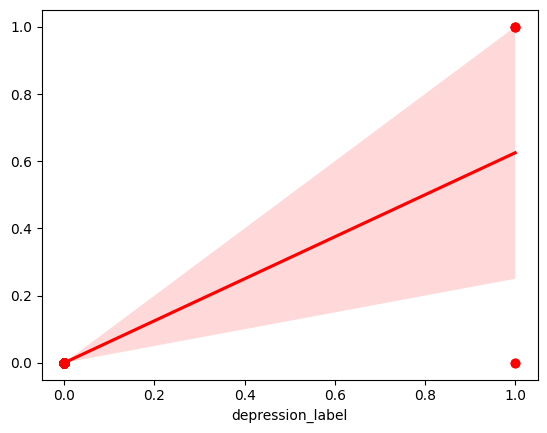

In [549]:
sns.regplot(x=y_test,y=y_predict,color='red')

In [550]:
pd.DataFrame(
    list(zip(models.keys(), r2_list)),
    columns=['Model Name', 'R2_Score']
).sort_values(by='R2_Score', ascending=False)

,Model Name,R2_Score
0,LinearRegression,1.000000
4,RandomForestRegressor,0.832509
2,Ridge,0.713647
5,DecisionTreeRegressor,0.486301
3,K-Neighbour Regressor,0.373288
1,Lasso,-0.000048


In [551]:
pred_df = pd.DataFrame({
    "Actual_Value": y_test,
    "Predicted_Value": y_predict_test,
    "Difference": y_test - y_predict_test
})

pred_df

,Actual_Value,Predicted_Value,Difference
1178,0,0.0,0.0
865,0,0.0,0.0
101,0,0.0,0.0
439,0,0.0,0.0
58,0,0.0,0.0
...,...,...,...
772,0,0.0,0.0
494,0,0.0,0.0
1027,0,0.0,0.0
806,0,0.0,0.0


In [552]:
print(X_train)

[[ 1.          0.          0.         ... -1.613389   -0.50851318
  -0.50851318]
 [ 0.          1.          1.         ...  0.86059194  2.14459906
   2.14459906]
 [ 0.          1.          0.         ...  0.50716609 -0.50851318
  -0.50851318]
 ...
 [ 1.          0.          1.         ...  1.21401779  1.17983098
   1.17983098]
 [ 0.          1.          0.         ...  1.56744364 -1.23208925
  -1.23208925]
 [ 0.          1.          0.         ...  0.86059194  0.45625491
   0.45625491]]


In [556]:
new_data = X_test[0].reshape(1, -1)

prediction = Log.predict(new_data)

print(prediction)

[0]
